# Income Classification using Logistic Regression

In this project, we will be using a dataset containing census information from the 1994 Census database to create a logistic regression model that predicts whether or not a person makes more than $50,000.

<br>

## Dataset
The original data set is available at the UCI Machine Learning Repository [here](https://archive.ics.uci.edu/dataset/20/census+income).

| Variable | Type | Description | Missing Values |
| :--- | :--- | :--- | :---: |
| **age** | Continuous (int64) | Age of the individual. | No |
| **workclass** | Categorical (object) | Employment status (e.g., Private, Self-emp, Government). | **Yes ("?")** |
| **fnlwgt** | Continuous (int64) | Final weight; number of people the census believe the entry represents. | No |
| **education** | Categorical (object) | Highest level of education achieved (e.g., Bachelors, Masters). | No |
| **education-num** | Continuous (int64) | Highest level of education completed in numerical form. | No |
| **marital-status** | Categorical (object) | Marital status (e.g., Married, Divorced, Never-married). | No |
| **occupation** | Categorical (object) | General type of occupation (e.g., Tech-support, Exec-managerial). | **Yes ("?")** |
| **relationship** | Categorical (object) | Relationship to household head (e.g., Wife, Husband). | No |
| **race** | Categorical (object) | Individual's race (e.g., White, Asian-Pac-Islander, Black). | No |
| **sex** | Binary (object) | Biological sex (Female, Male). | No |
| **capital-gain** | Continuous (int64) | Capital gains recorded from investments. | No |
| **capital-loss** | Continuous (int64) | Capital losses recorded from investments. | No |
| **hours-per-week** | Continuous (int64) | Number of hours worked per week. | No |
| **native-country** | Categorical (object) | Country of origin (e.g., United-States, Mexico, Philippines). | **Yes ("?")** |
| **income** (Target) | Binary (object) | The prediction goal: Earns >50K or <=50K per year. | No |

<br>
<br>

<b>Missing Values</b>: Several categorical variables (Workclass, Occupation, Native-Country) contain missing values represented by a "?" string rather than standard NaN values. 

<b>Feature Redundancy</b>: education and education-num represent the same information. Drop the categorical education column and keep the numerical version.

<b>High Skewness</b>: Variables like capital-gain and capital-loss are often highly skewed (mostly zeros). 

<br>

In [1]:
import pandas as pd 
import numpy as np

np.float = float
np.int = int

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 
            'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv('adult.data', header=None, names=col_names)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


<br>

# Data Cleaning 

According to the UCI Machine Learning repository, the only columns with missing values are <b>Work Class</b>, <b>occupuation</b> and <b>native-country</b>. \
We carry out EDA to check that these are the only missing columns. 

A majority (9/15) columns are type object. Therefore, we also check for whitespace that can impact our analysis. 

<br>

In [2]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object


<br>

### Check for whitespace

We found all 32,561 object rows contain some type of whitespace. This may not be impactful in our analysis, but it'll be easiest to just remove these. 

<br>

In [3]:
# check for whitespace 
for col in df.select_dtypes(include=['object']):
    whitespace_count = (df[col] != df[col].str.strip()).sum()
    print(f'{col} column has {whitespace_count} rows with whitespace.')

workclass column has 32561 rows with whitespace.
education column has 32561 rows with whitespace.
marital-status column has 32561 rows with whitespace.
occupation column has 32561 rows with whitespace.
relationship column has 32561 rows with whitespace.
race column has 32561 rows with whitespace.
sex column has 32561 rows with whitespace.
native-country column has 32561 rows with whitespace.
income column has 32561 rows with whitespace.


In [4]:
# Remove whitespace for columns with "object" type 
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

In [5]:
# check for whitespace 
for col in df.select_dtypes(include=['object']):
    whitespace_count = (df[col] != df[col].str.strip()).sum()
    print(f'{col} column has {whitespace_count} rows with whitespace.')

workclass column has 0 rows with whitespace.
education column has 0 rows with whitespace.
marital-status column has 0 rows with whitespace.
occupation column has 0 rows with whitespace.
relationship column has 0 rows with whitespace.
race column has 0 rows with whitespace.
sex column has 0 rows with whitespace.
native-country column has 0 rows with whitespace.
income column has 0 rows with whitespace.


<br>

## Check for Missingness

A first check on missingness shows no columns are "missing" however, we know some columns contain missing values from the description on UCI Machine Learning repository. \
We check for the unique values in the columns highlighted by UCI Machine Learning and find the missing values are denoted by "?" 

<br>

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [7]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [8]:
df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [9]:
df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', '?', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

<br>

## Handling Missingness

We replace all '?' with np.NaN and check remaining object columns for missing values. Finally, we check missing values in the entire dataset. 

<br>

In [10]:
df.replace('?', np.NaN, inplace=True)

In [11]:
for col in df.select_dtypes(include=['object']):
    print(f"{col} columns: ")
    print('-'*len(f"{col} columns: "))
    print(df[col].unique())
    print('')
    print('')

workclass columns: 
-------------------
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']


education columns: 
-------------------
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']


marital-status columns: 
------------------------
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']


occupation columns: 
--------------------
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']


relationship columns: 
----------------------
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']


race columns: 
--------------
['White' 'Black' 'A

In [12]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

<br>

# EDA and Logistic Regression Assumptions

#### Check the dataset for imbalance  
we can see the data set is inbalanced, since the <= 50K dataset is about 3 times larger than the >50K dataset.  

<br>

In [13]:
#1. Check Class Imbalance
df['income'].value_counts()

<=50K    24720
>50K      7841
Name: income, dtype: int64

<br>

#### Check the dataset for multicollinearity  

We will use the following columns as features in our logistic regression: <i>['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'sex','race', 'education']</i>

The correlation heatmap indicates that the independent variables selected for this logistic regression model do not exhibit strong linear relationships with one another. \
Most feature pairs show coefficients near zero, represented by the darker regions of the plot, which suggests that the "no multicollinearity" assumption is generally satisfied.\
While some negative correlation exists between dummy-encoded categories (such as specific race or education levels), this is a mathematical expectation of mutually exclusive \
categorical variables. Because there are no high positive or negative correlations (typically defined as $|r| > 0.7$) between distinct predictors like age, capital-gain, and \
hours-per-week, the model is unlikely to suffer from inflated standard errors or unstable coefficient estimates.

<br>

In [14]:
# Feature columns for logistic regression
feature_cols = ['age','capital-gain', 'capital-loss', 'hours-per-week', 'sex','race', 'education']

X = pd.get_dummies(df[feature_cols], drop_first=True)
X_corr = X.corr()

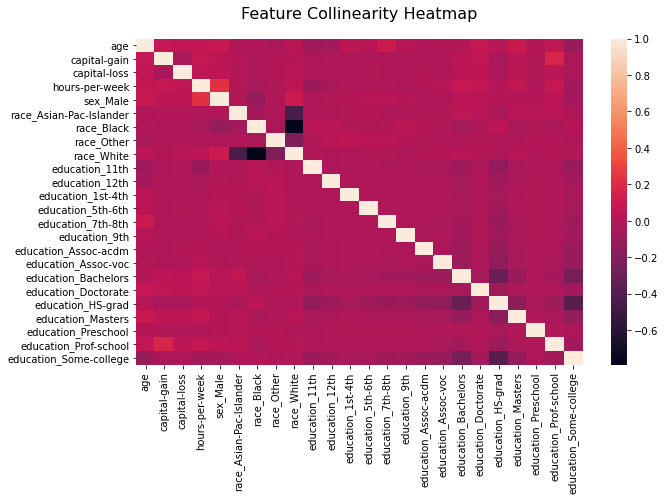

In [15]:
fig, ax = plt.subplots(figsize=(10, 6));
sns.heatmap(X_corr);
ax.set_title('Feature Collinearity Heatmap', fontsize=16, pad=20)
plt.savefig('feature_correlation_heatmap.png')

## Logistic Regression Model 

we break up the data into 80% training to build the model and 20% testing to evaluate model performance. \
We select random_state = 1 for reproducibility in the testing of the model. 

### Model Configuration and Hyperparameter Justification

The Logistic Regression model was initialized with specific hyperparameters to optimize performance on the high-dimensional Census dataset:
- Penalty (`l1`): Lasso regularization (L1) was selected to encourage sparsity in the model. Since the dataset contains many dummy-encoded categorical variables \
(such as education levels and occupations), L1 helps perform automated feature selection by shrinking the coefficients of less influential variables to zero.

- Regularization Strength (`C=0.05`): A smaller value of $C$ represents stronger inverse regularization. This choice penalizes large coefficients, which prevents \
the model from over-adjusting to noise or outliers in the training data, thereby improving its ability to generalize to the unseen test set.

- Solver (`liblinear`): The liblinear solver was chosen because it is an efficient algorithm for small to medium-sized datasets and is specifically designed to support \
the L1 penalty, which is not compatible with standard solvers like lbfgs.

By implementing these settings, the model strikes a balance between complexity and interpretability, ensuring that only the most significant demographic drivers of income \
are retained in the final decision boundary.

<br>

In [16]:
# Create a binary output variable y using the income column from DataFrame (df)
y = df.income.map({'<=50K':0, '>50K':1})

# Split the features (X) and target (y) into training and testing sets using sklearn train_test_split function
# train_size=0.8 (allocate 80% of the data to build the model)
# test_size=0.2 (reserve 20% of the data to evaluate model performance)
# random_state=1 (ensures the split is reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

# Create the logisitc regression model using defined penalty, Regularization and solver  
model = LogisticRegression(penalty='l1', C=0.05, solver='liblinear')

# Fit the logistic regression model using the training data 
model.fit(X_train, y_train)

# Create predictions using the regression model 
y_pred = model.predict(X_test)

### Interpretation of Model Coefficients and Intercept

The coefficients represent the log-odds impact of each feature on the probability of an individual earning more than 50K. \
The use of L1 regularization resulted in  some coefficients shrining to zero, removing these features from the model - preventing overfitting.

<br>

#### Key Findings from Coefficients:

- <b>Feature Selection (Sparsity)</b>: L1 penalty identified redundant/non-predictive categories \
[`race_White`, `race_Asian-Pac-Islander`, `race_Other`, `education_12th`, `education_1st-4th`, `education_HS-grad`, `education_Preschool`]

- <b>Education Impact</b>: Higher education show the strongest positive influence on income. `education_Prof-school` - (1.817991), `education_Doctorate` - (1.787714) \
and `education_Masters` - (1.586502) have the highest weights, significantly increasing the likelihood of belonging to the high-income bracket compared to the baseline.

- <b>Demographic and Financial Factors</b>: `sex_Male` - (1.014620) shows a positive correlation with higher income. `age` - (0.035475) shows a small correlation \
however, this is a continuous variable meaning the impact could compound for every year of age. \

- <b>Negative Predictors</b>: Disappointingly (while unsurprisingly), `race_Black` - (-0.440399) is the only race negatively correlated with higher income. \
In comparison, `education_5th-6th` - (-0.409770) is weighted similarly by the model, illustrating the systemic disparities present in the 1994 Census data. \
This comparison showcases the significant impact of racial identity on economic outcomes, independent of other factors. \
Additionally, lwer education levels such as `education_7th-8th` (-0.892272) carry the strongest negative coefficients, indicating a markedly decreased probability of earning above 50K. 

<br>

#### Interpretation of the Intercept: 
The intercept <b>(-5.37285918)</b> represents the log-odds of the taget variable when all independent variables are zero. \
This represents that for a baseline individual (young, no education, no capital gains) the probability of earning >\$50K is very low. 

<br>

In [17]:
coefficients = model.coef_
intercept = model.intercept_

cols = X.columns

dict = {'var':cols, 'coef':coefficients[0]}
var_coeff_df = pd.DataFrame(dict).sort_values(by='coef').reset_index(drop=True)
var_coeff_df = var_coeff_df[var_coeff_df['coef'] != 0]
print(var_coeff_df)

                       var      coef
0        education_7th-8th -0.897357
1           education_11th -0.584148
2            education_9th -0.506847
3        education_5th-6th -0.407400
4               race_Black -0.390801
11            capital-gain  0.000314
12            capital-loss  0.000666
13          hours-per-week  0.031328
14                     age  0.036178
15              race_White  0.047272
16  education_Some-college  0.376456
17     education_Assoc-voc  0.539518
18    education_Assoc-acdm  0.564037
19                sex_Male  1.023686
20     education_Bachelors  1.273361
21       education_Masters  1.592085
22     education_Doctorate  1.791924
23   education_Prof-school  1.816638


---

### Model Evaluation and Performance Metrics

<br>
    
<u>recall</u>: $\hspace{25mm}$  Accuracy: $\frac{(𝑇𝑃 + 𝑇𝑁)}{(𝑇𝑃 + 𝐹𝑃 + 𝑇𝑁 + 𝐹𝑁)}$

<br>

The model achieved an accuracy score of 82.78% (0.8277291570704745) on the unseen test set, indicating a strong ability to generalize across the broader population.
However, an analysis on the confusion matrix provides a more nuanced view of how the model handled the two income classes: 

|  | Predict Negative (<=50K) | Predict Positive (>50K) | | 
| :--- | :---: | :---: | :---: |
| Actual Negative | 4,784 (TN) | 242 (FP) | <u>Total</u>: 5,026 |
| Actual Positive | 880 (FN) | 607 (TP) | <u>Total</u>: 1,487 |

#### Key Observations
- The model performs well when identifying individuals who earn <=50K. Out of 5,026 actual negative cases, it correctly classified 4,784 of them, resulting in a very low false positive rate.

- The model struggles to identify high-income earners (>50K). It missed 880 (false negatives) and correctly identified only 607 (true positives). This suggests that high-income earners in this dataset may share many demographic features with the lower-income bracket, making them harder for a linear model to distinguish. 

- The disparity in performance between the two classes likely stems from the inherent imbalance in the Census data, where the majority of observations fall into the lower-income category.

<br>

This performance profile is typical for a Logistic Regression model on this specific dataset. While the accuracy is high, the model is "conservative" in its predictions, favoring the majority class unless there is very strong evidence of high income (such as high capital gains or advanced degrees).

---

In [18]:
accuracy = accuracy_score(y_test, y_pred)

test_conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred), 
                               index=['Actual Neg.', 'Actual Pos.'],
                               columns=['Predict Neg.', 'Predict Pos.'])

In [19]:
print(f'Model Accuracy: {accuracy}')
print('')
print('-'*len('Confusion Matrix:'))
print('Confusion Matrix:')
print('-'*len('Confusion Matrix:'))
print(test_conf_matrix)

Model Accuracy: 0.8278826961461692

-----------------
Confusion Matrix:
-----------------
             Predict Neg.  Predict Pos.
Actual Neg.          4783           243
Actual Pos.           878           609


-------------

## Ranking Feature Importance using Model Coefficients

#### Visualizing Feature Importance and Model Sparsity

This bar chart provides a clear ranking of the features by their influence on the model’s predictions. By visualizing the coefficients after L1 regularization, we can see exactly which demographic and financial factors the model prioritized to determine if an individual earns over 50K.

The visualization confirms that higher education is the single most powerful positive predictor in this dataset, with `education_Prof-school`, `education_Doctorate` and `education_Masters` leading the impact. Conversely, lower levels of education—specifically `education_7th-8th`—represent the most significant negative pressure on income probability. Mid-range bars like `sex_Male` and `education_Bachelors` show a strong but secondary influence.

The "gaps" in the chart where bars are missing, such as for certain race categories or capital loss, demonstrate the L1 penalty in action. These variables were determined to be non-predictive or redundant, so the model effectively "zeroed them out" to create a simpler, more generalized decision boundary. This visual confirms that the model is focusing only on the most statistically significant drivers of socio-economic status.

-------------


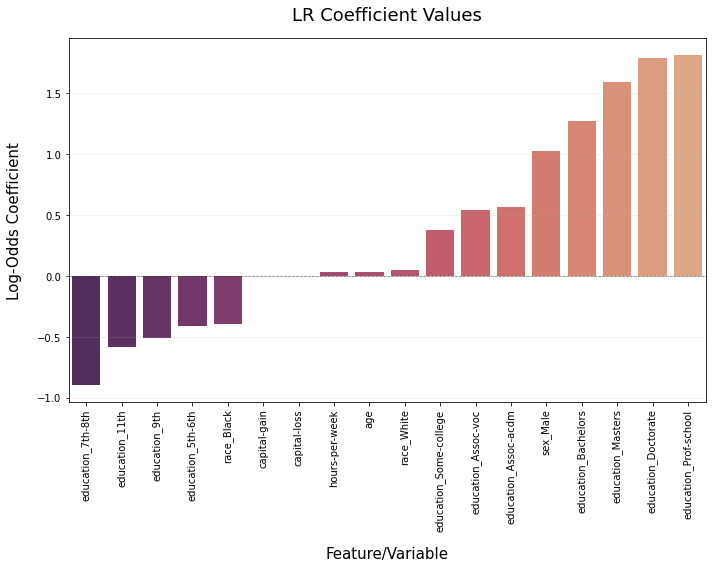

In [20]:
# Create a color list: red for negative, blue for positive
colors = ['#d65f5f' if x < 0 else '#5f9ed1' for x in var_coeff_df['coef']]

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(x='var', y='coef', data=var_coeff_df, palette='flare_r');
plt.axhline(0, color='black', linestyle='--', linewidth=0.75, alpha=0.5)
plt.title('LR Coefficient Values', pad=18, size=18)
plt.ylabel('Log-Odds Coefficient', labelpad=15, size=15)
plt.xlabel('Feature/Variable', labelpad=15, size=15)
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('logistic_regression_feature_importance.png')

----------------------

### ROC Cure and AUC Score Analysis

The receicver operating characteristic (ROC) curve and the area under curve (AUC) score provide a thredhold-independent evaluation of the model's ability to distinguish between the two income classes. 

- ROC AUC Score (0.85): AUC score is considered good. It indicates theres an 85% chance the model will distinguish between a randomly selected high-income earner and a randomly selected low-income earner. The model far exceeds a random guess. 

- Curve Profile: The orange curve stays above the diagonal dashed line (no-skill baseline). The steepness of the curve at the start shows the model can achieve a high true positive rate (sensitivity) while maintaining a relatively low false positive rate. 

- Tade-off Visbility: As we move along the curve, we can see the increase in the model's ability to catch more high-income earners (higher TPR), which results in more low-income earners being incorrectly flagged (higher FPR). 

This metric shows that while the confusion matrix showed some difficulty with recall at a default 0.5 threshold, the underlying probability rankings produced by the model are robust and reliable  for classification. 

----------------------

-------------------
ROC AUC Score: 0.85
-------------------



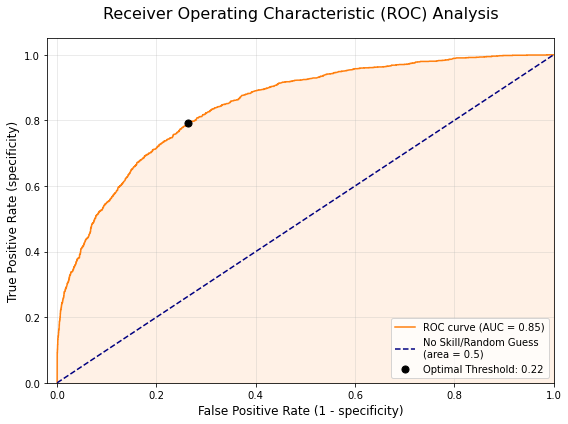

In [21]:
#Get predicted probabilities for the positive class
# We need probabilities, not just the final class predictions
y_probs = model.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, and thresholds using roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate the AUC score (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_probs)
print('-'*len(f"ROC AUC Score: {roc_auc:.2f}"))
print(f"ROC AUC Score: {roc_auc:.2f}")
print('-'*len(f"ROC AUC Score: {roc_auc:.2f}") + '\n')

# Calculate Youden's J-Statistic to find the optimal threshold
# J = TPR – FPR
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
opt_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(8, 6))

# Fill the area under the curve
plt.fill_between(fpr, tpr, color='tab:orange', alpha=0.1)

# Plot the main ROC curve
plt.plot(fpr, tpr, color='tab:orange', label=f'ROC curve (AUC = {roc_auc:.2f})');

# Plot the 'No Skill' baseline
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='No Skill/Random Guess \n(area = 0.5)');

# Mark the optimal threshold point
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='black', s=50, zorder=5, 
            label=f'Optimal Threshold: {opt_threshold:.2f}')

plt.xlabel('False Positive Rate (1 - specificity)', fontsize=12)
plt.ylabel('True Positive Rate (specificity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Analysis', fontsize=16, pad=20)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3);
plt.legend(loc=4);
plt.tight_layout();

# Save with a professional filename
plt.savefig('roc_auc_curve_analysis.png', dpi=300)

--------------------------------------------
## Project Conclusion and Key Insights

This project successfully implemented a Logistic Regression model to predict whether an individual earns more than 50K annually based on 1994 Census data. By utilizing L1 (Lasso) regularization, the model achieved an overall accuracy of 82.77% and a robust ROC AUC score of 0.85, demonstrating strong discriminative power.

The most critical insight from the feature analysis is the overwhelming impact of specialized education on income potential. Advanced degrees—specifically Masters, Doctorate and Professional school levels—were the strongest positive predictors in the model. Conversely, the analysis revealed significant systemic disparities, as evidenced by the negative correlation associated with specific racial and gender categories, even when controlling for other variables like hours worked and age.

While the model is highly effective at identifying lower-income earners (high specificity), the confusion matrix highlights a common challenge in imbalanced datasets: a lower recall for the high-income class. This suggests that for future iterations, exploring ensemble methods could help the model better capture the nuanced demographic profiles of high-income individuals. Ultimately, this notebook serves as a baseline for understanding how demographic markers serve as proxies for economic mobility.

--------------------------------------------